# EDA — Mental Health Dataset
**Capstone Project: DerMind — Platform Kesehatan Digital Berbasis AI**

Notebook ini berisi Exploratory Data Analysis (EDA) lengkap untuk dataset Mental Health.
Dataset yang digunakan: `master_mental_health_clean.csv` (52.940 teks, 7 label kondisi mental)

**Pertanyaan Bisnis yang dijawab:**
- PB1: Kondisi mental health apa yang paling dominan berdasarkan data teks pengguna?
- PB2: Apakah pola teks (panjang, kata kunci) dapat membedakan kondisi mental health secara signifikan?


## 1. Import Library & Load Data

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# ── DerMind color palette ──────────────────────────────────
TEAL     = '#14B8A6'
TEAL2    = '#0D9488'
CYAN     = '#06B6D4'
BG_DARK  = '#0F172A'
BG_CARD  = '#1E293B'
TEXT_CLR = '#F1F5F9'
PALETTE  = ['#14B8A6','#06B6D4','#3B82F6','#8B5CF6','#F59E0B','#EF4444','#10B981']

plt.rcParams.update({
    'figure.facecolor': BG_DARK,
    'axes.facecolor'  : BG_CARD,
    'axes.edgecolor'  : '#334155',
    'axes.labelcolor' : TEXT_CLR,
    'xtick.color'     : TEXT_CLR,
    'ytick.color'     : TEXT_CLR,
    'text.color'      : TEXT_CLR,
    'grid.color'      : '#334155',
    'figure.dpi'      : 120,
    'font.size'       : 11,
})

# Load data (sesuaikan path jika perlu)
df = pd.read_csv('master_mental_health_clean.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (52940, 6)
Columns: ['text', 'text_clean', 'label', 'word_count', 'char_count', 'source']


,text,text_clean,label,word_count,char_count,source
0,oh my gosh,oh my gosh,Anxiety,3,10,combined
1,"trouble sleeping, confused mind, restless hear...","trouble sleeping, confused mind, restless hear...",Anxiety,10,64,combined
2,"All wrong, back off dear, forward doubt. Stay ...","all wrong, back off dear, forward doubt. stay ...",Anxiety,14,78,combined
3,I've shifted my focus to something else but I'...,i've shifted my focus to something else but i'...,Anxiety,11,61,combined
4,"I'm restless and restless, it's been a month n...","i'm restless and restless, it's been a month n...",Anxiety,14,72,combined


## 2. Overview Dataset

In [9]:
print('=== INFO DATASET ===')
print(f'Total data    : {len(df):,} baris')
print(f'Total kolom   : {df.shape[1]}')
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'Duplikat      : {df.duplicated().sum()}')
print()
print('=== DISTRIBUSI SUMBER DATA ===')
print(df['source'].value_counts())
print()
print('=== STATISTIK WORD COUNT ===')
print(df['word_count'].describe())

=== INFO DATASET ===
Total data    : 52,940 baris
Total kolom   : 6
Missing values: 0
Duplikat      : 0

=== DISTRIBUSI SUMBER DATA ===
source
combined    50690
reddit       2250
Name: count, dtype: int64

=== STATISTIK WORD COUNT ===
count    52940.000000
mean       118.914583
std        169.256484
min          1.000000
25%         17.000000
50%         67.000000
75%        157.000000
max       6300.000000
Name: word_count, dtype: float64


## 3. Distribusi Label (PB1)

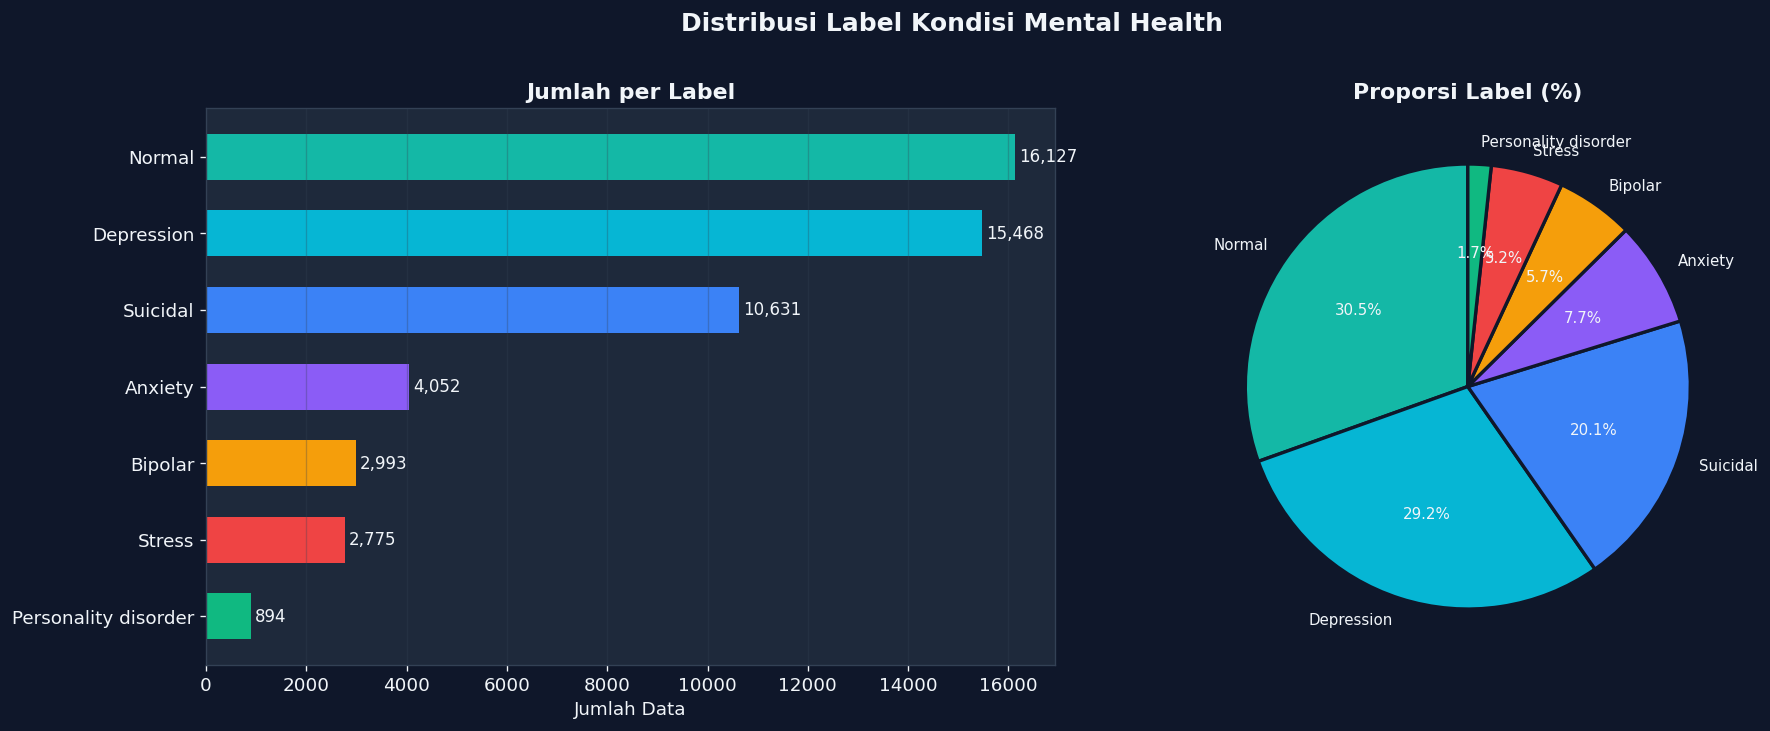


Imbalance ratio: 18.0:1 (Normal vs Personality disorder)


In [10]:
vc = df['label'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Distribusi Label Kondisi Mental Health', fontsize=15, fontweight='bold', color=TEXT_CLR, y=1.01)

# Bar chart
bars = axes[0].barh(vc.index, vc.values, color=PALETTE[:len(vc)], edgecolor='none', height=0.6)
for bar, val in zip(bars, vc.values):
    axes[0].text(bar.get_width() + 80, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=10, color=TEXT_CLR)
axes[0].set_xlabel('Jumlah Data', color=TEXT_CLR)
axes[0].set_title('Jumlah per Label', color=TEXT_CLR, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    vc.values, labels=vc.index, autopct='%1.1f%%',
    colors=PALETTE[:len(vc)], startangle=90,
    wedgeprops={'edgecolor': BG_DARK, 'linewidth': 2}
)
for t in texts + autotexts:
    t.set_color(TEXT_CLR)
    t.set_fontsize(9)
axes[1].set_title('Proporsi Label (%)', color=TEXT_CLR, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_mh_01_distribusi_label.png', bbox_inches='tight', facecolor=BG_DARK)
plt.show()
print(f'\nImbalance ratio: {vc.max()/vc.min():.1f}:1 ({vc.idxmax()} vs {vc.idxmin()})')

> **Insight PB1:** Kondisi mental yang paling dominan adalah **Normal** (30.6%) dan **Depression** (29.2%), bersama menyumbang ~60% data. **Personality Disorder** adalah kelas paling sedikit. Imbalance ratio yang tinggi (18:1) berarti model AI wajib menggunakan `class_weight='balanced'` atau teknik oversampling.

## 4. Distribusi per Sumber Data

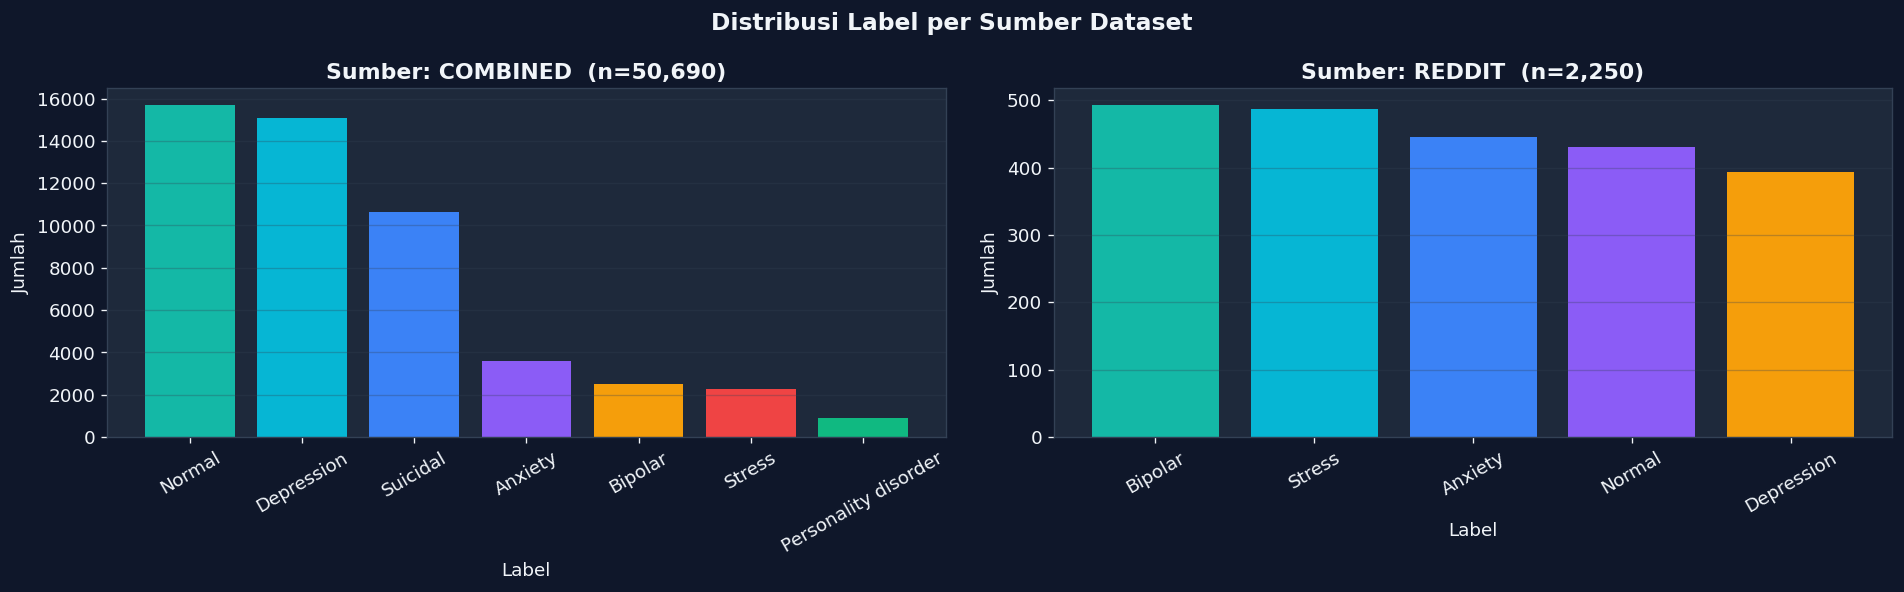

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Distribusi Label per Sumber Dataset', fontsize=14, fontweight='bold', color=TEXT_CLR)

for idx, src in enumerate(df['source'].unique()):
    sub = df[df['source'] == src]['label'].value_counts()
    axes[idx].bar(sub.index, sub.values, color=PALETTE[:len(sub)], edgecolor='none')
    axes[idx].set_title(f'Sumber: {src.upper()}  (n={len(df[df["source"]==src]):,})',
                         color=TEXT_CLR, fontweight='bold')
    axes[idx].set_xlabel('Label', color=TEXT_CLR)
    axes[idx].set_ylabel('Jumlah', color=TEXT_CLR)
    axes[idx].tick_params(axis='x', rotation=30)
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('eda_mh_02_per_sumber.png', bbox_inches='tight', facecolor=BG_DARK)
plt.show()

## 5. Analisis Panjang Teks (PB2)

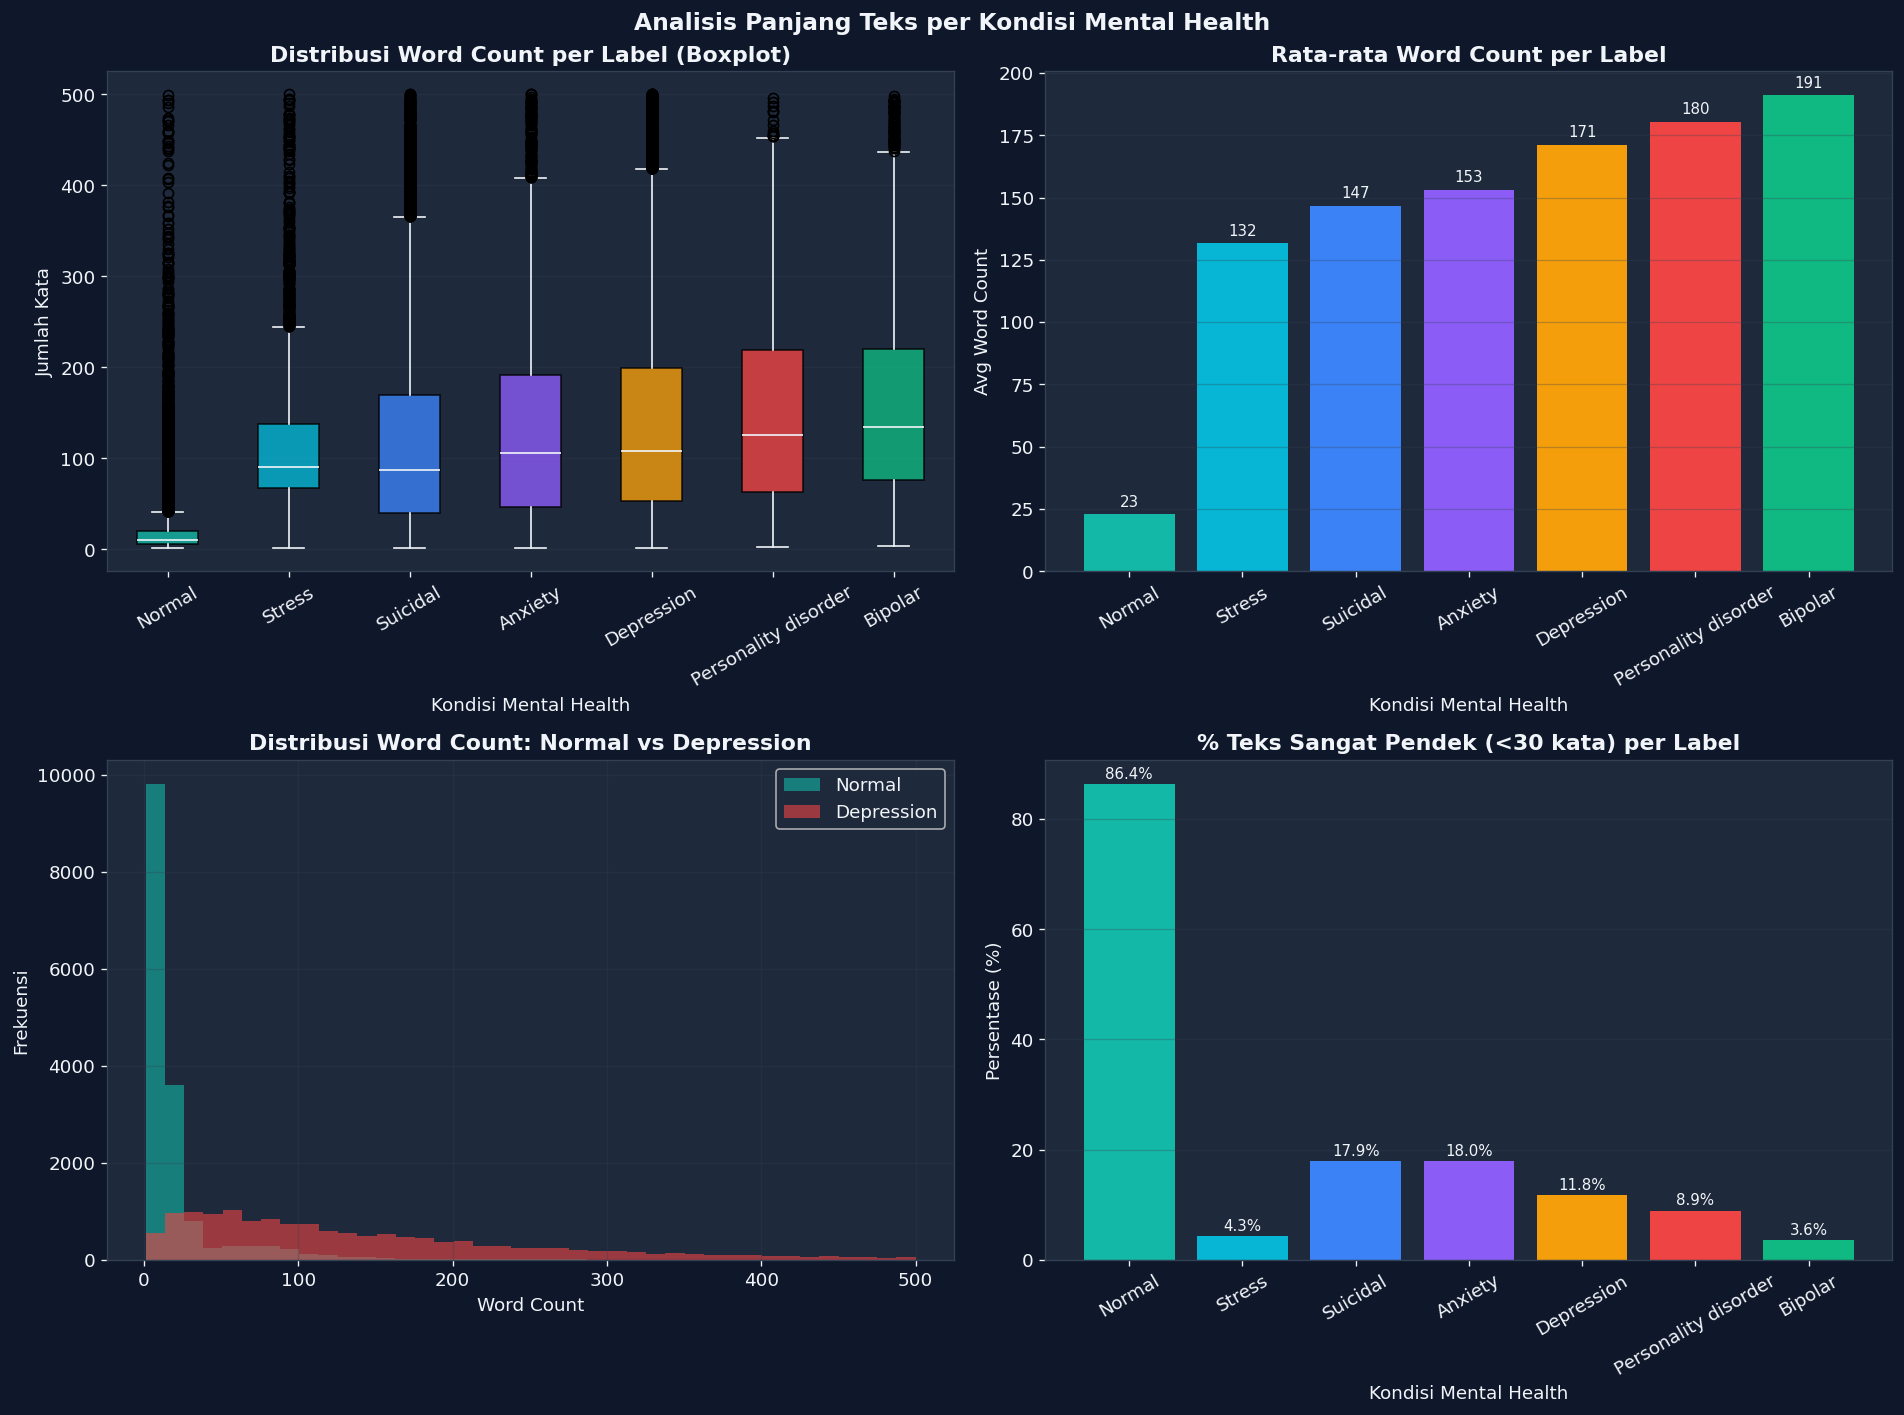

In [12]:
label_order = df.groupby('label')['word_count'].median().sort_values().index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Analisis Panjang Teks per Kondisi Mental Health', fontsize=14, fontweight='bold', color=TEXT_CLR)

# 1. Boxplot word count
df_cap = df[df['word_count'] <= 500].copy()
data_box = [df_cap[df_cap['label'] == l]['word_count'].values for l in label_order]
bp = axes[0,0].boxplot(data_box, labels=label_order, patch_artist=True, notch=False)
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
for element in ['whiskers','caps','medians']:
    for line in bp[element]: line.set_color(TEXT_CLR)
axes[0,0].set_title('Distribusi Word Count per Label (Boxplot)', color=TEXT_CLR, fontweight='bold')
axes[0,0].set_xlabel('Kondisi Mental Health', color=TEXT_CLR)
axes[0,0].set_ylabel('Jumlah Kata', color=TEXT_CLR)
axes[0,0].tick_params(axis='x', rotation=30)
axes[0,0].grid(axis='y', alpha=0.3)

# 2. Bar rata-rata word count
avg_wc = df.groupby('label')['word_count'].mean().reindex(label_order)
bars = axes[0,1].bar(avg_wc.index, avg_wc.values, color=PALETTE[:len(avg_wc)], edgecolor='none')
for bar, val in zip(bars, avg_wc.values):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                    f'{val:.0f}', ha='center', va='bottom', fontsize=9, color=TEXT_CLR)
axes[0,1].set_title('Rata-rata Word Count per Label', color=TEXT_CLR, fontweight='bold')
axes[0,1].set_xlabel('Kondisi Mental Health', color=TEXT_CLR)
axes[0,1].set_ylabel('Avg Word Count', color=TEXT_CLR)
axes[0,1].tick_params(axis='x', rotation=30)
axes[0,1].grid(axis='y', alpha=0.3)

# 3. Histogram word count Normal vs Depression
for label, color in zip(['Normal','Depression'], [TEAL, '#EF4444']):
    sub = df[(df['label'] == label) & (df['word_count'] <= 500)]['word_count']
    axes[1,0].hist(sub, bins=40, alpha=0.6, label=label, color=color, edgecolor='none')
axes[1,0].set_title('Distribusi Word Count: Normal vs Depression', color=TEXT_CLR, fontweight='bold')
axes[1,0].set_xlabel('Word Count', color=TEXT_CLR)
axes[1,0].set_ylabel('Frekuensi', color=TEXT_CLR)
axes[1,0].legend()
axes[1,0].grid(alpha=0.3)

# 4. % teks sangat pendek (<30 kata) per label
pct_short = df.groupby('label').apply(lambda x: (x['word_count'] < 30).mean() * 100).reindex(label_order)
bars2 = axes[1,1].bar(pct_short.index, pct_short.values, color=PALETTE[:len(pct_short)], edgecolor='none')
for bar, val in zip(bars2, pct_short.values):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{val:.1f}%', ha='center', va='bottom', fontsize=9, color=TEXT_CLR)
axes[1,1].set_title('% Teks Sangat Pendek (<30 kata) per Label', color=TEXT_CLR, fontweight='bold')
axes[1,1].set_xlabel('Kondisi Mental Health', color=TEXT_CLR)
axes[1,1].set_ylabel('Persentase (%)', color=TEXT_CLR)
axes[1,1].tick_params(axis='x', rotation=30)
axes[1,1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('eda_mh_03_panjang_teks.png', bbox_inches='tight', facecolor=BG_DARK)
plt.show()

> **Insight PB2:** Panjang teks secara signifikan membedakan kondisi mental health. **Normal** menghasilkan teks sangat pendek (rata-rata <30 kata), sedangkan kondisi klinis seperti **Bipolar** dan **Personality Disorder** menghasilkan narasi panjang (100–180+ kata). Fitur `word_count` dan `char_count` harus dijadikan fitur tambahan saat training model NLP.

## 6. Analisis Kata Kunci per Label

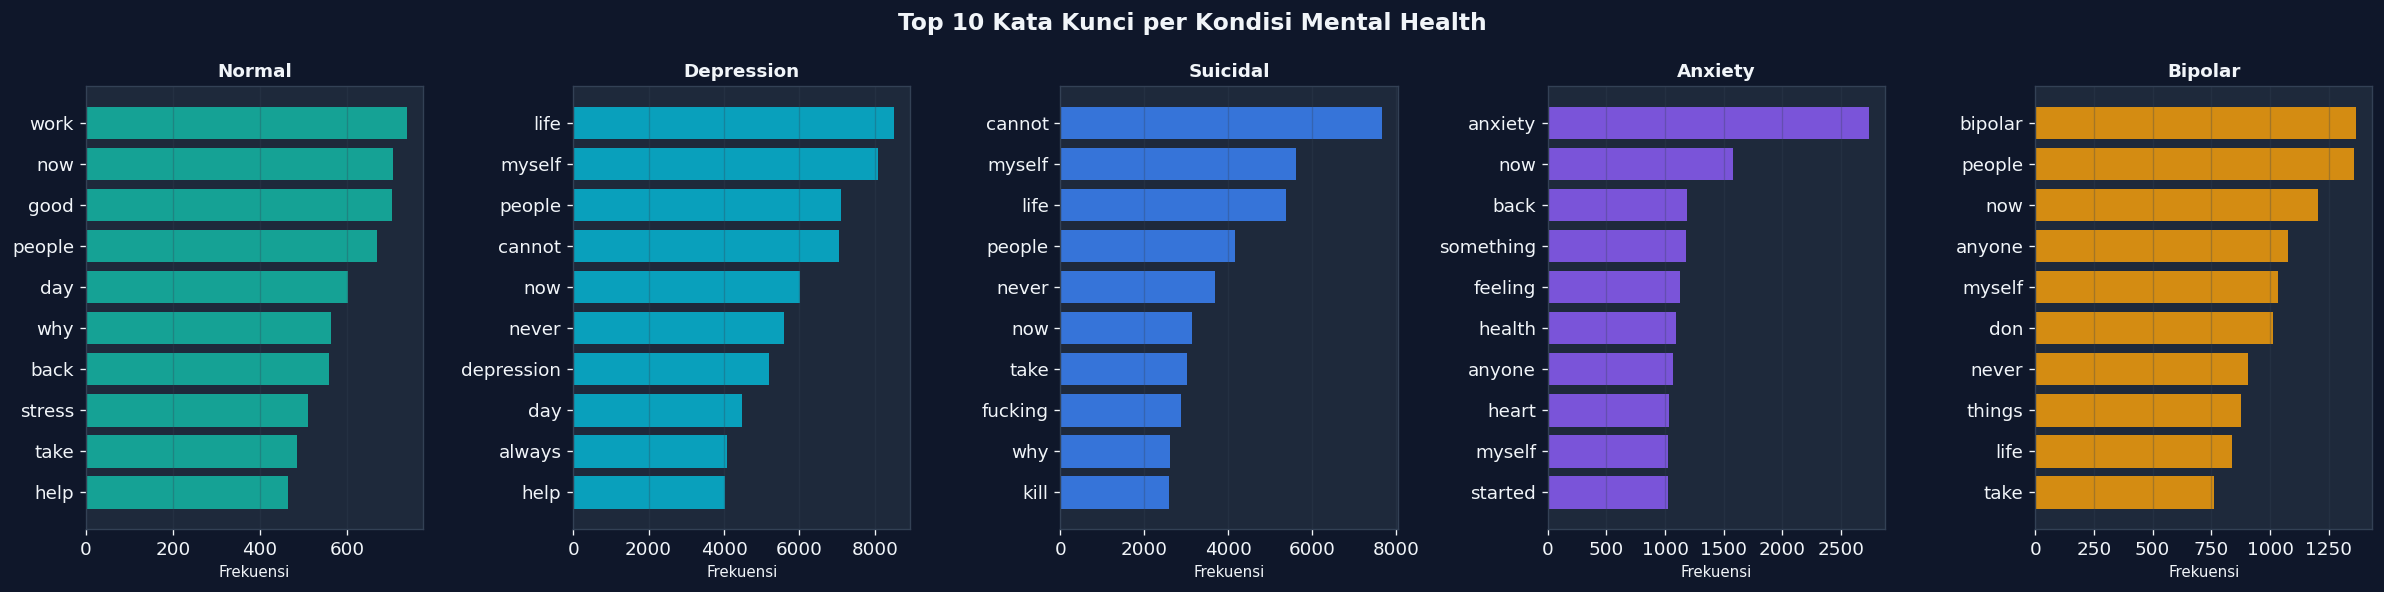

In [13]:
STOPWORDS = set(['i','the','a','and','to','of','is','in','it','my','that','for',
                 'me','was','on','are','have','been','with','at','this','but','not',
                 'they','so','if','do','be','we','an','or','as','he','she','his',
                 'her','their','you','your','from','all','had','when','what','there',
                 'were','about','him','can','just','would','will','one','out','up',
                 'no','by','like','get','got','its','also','more','than','then',
                 'into','some','what','which','who','how','very','still','even',
                 'after','before','could','should','because','am','has','does',
                 'did','other','been','being','those','these','them','such',
                 'through','between','after','where','much','too','only','own',
                 'same','both','here','again','any','over','most','know','think',
                 'feel','want','need','make','see','go','going','really','time'])

labels_show = ['Normal','Depression','Suicidal','Anxiety','Bipolar']
fig, axes = plt.subplots(1, len(labels_show), figsize=(20, 5))
fig.suptitle('Top 10 Kata Kunci per Kondisi Mental Health', fontsize=14, fontweight='bold', color=TEXT_CLR)

for ax, label, color in zip(axes, labels_show, PALETTE):
    texts = df[df['label'] == label]['text_clean'].dropna().str.lower().str.split()
    words = [w for ws in texts for w in ws if w.isalpha() and w not in STOPWORDS and len(w) > 2]
    top10 = Counter(words).most_common(10)
    words_l, counts_l = zip(*top10)
    ax.barh(list(words_l)[::-1], list(counts_l)[::-1], color=color, alpha=0.85, edgecolor='none')
    ax.set_title(label, color=TEXT_CLR, fontweight='bold', fontsize=11)
    ax.set_xlabel('Frekuensi', color=TEXT_CLR, fontsize=9)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('eda_mh_04_kata_kunci.png', bbox_inches='tight', facecolor=BG_DARK)
plt.show()

## 7. Heatmap Korelasi Gejala (Mental Disorder Classification)

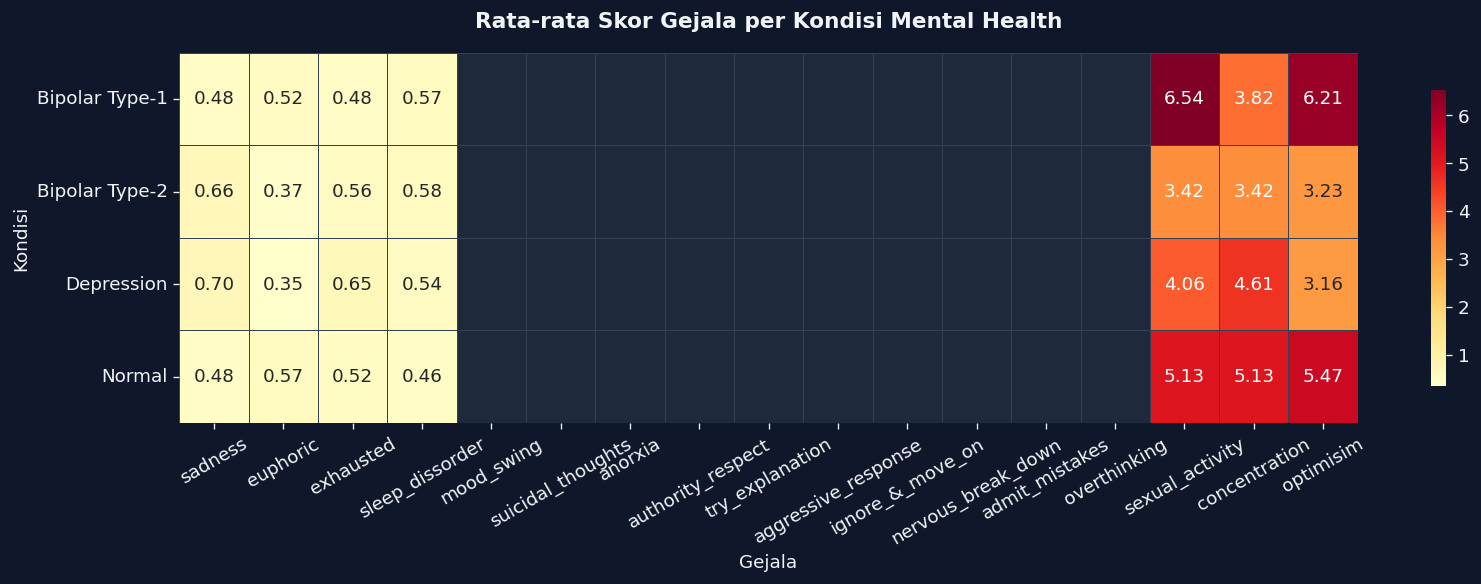

In [14]:
df_dis = pd.read_csv('mental_disorder_classification_cleaned.csv')

# Encode Yes/No to 1/0
df_enc = df_dis.copy()
for col in df_enc.columns:
    if df_enc[col].dtype == object and col != 'label':
        df_enc[col] = df_enc[col].map({'Yes':1,'No':0,'Sometimes':0.5,'Usually':0.75,'Seldom':0.25})

symptom_cols = [c for c in df_enc.columns if c != 'label']
heatmap_data = df_enc.groupby('label')[symptom_cols].mean()

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='YlOrRd',
            ax=ax, linewidths=0.5, linecolor='#334155',
            cbar_kws={'shrink': 0.8})
ax.set_title('Rata-rata Skor Gejala per Kondisi Mental Health',
              color=TEXT_CLR, fontweight='bold', fontsize=13, pad=15)
ax.set_xlabel('Gejala', color=TEXT_CLR)
ax.set_ylabel('Kondisi', color=TEXT_CLR)
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('eda_mh_05_heatmap_gejala.png', bbox_inches='tight', facecolor=BG_DARK)
plt.show()

## 8. Kesimpulan EDA Mental Health

| # | Temuan | Implikasi untuk Model |
|---|--------|----------------------|
| 1 | Dataset imbalanced (Normal 30.6% vs Personality Disorder 1.7%) | Gunakan `class_weight='balanced'` atau SMOTE |
| 2 | Normal: teks sangat pendek (<30 kata), kondisi klinis 100-180+ kata | Tambahkan `word_count` sebagai fitur numerik |
| 3 | Setiap kondisi punya kata kunci yang distinctif | TF-IDF + SVM/BERT cocok untuk klasifikasi |
| 4 | Suicidal: kata 'suicide','kill','pain' dominan | Perlu filter konten sensitif di chatbot |
| 5 | 95.3% data dari sumber 'combined', 4.7% reddit | Distribusi sumber tidak seimbang |

**Rekomendasi model:** TF-IDF + Logistic Regression/SVM sebagai baseline, lalu BERT/IndoBERT untuk akurasi lebih tinggi.